# Microbial Signal in Viromes

This notebook documents bacterial reference genomes detected in the 36 viromes and how geNomad viral regions and explicit proviruses were accounted for.

A bacterial reference genome is reported when at least 30% of its bases are covered in one or more samples. Detection uses the geNomad-viral-region-masked reference. For detected genomes, the notebook reports taxonomy and only geNomad regions explicitly labelled `Provirus` as integrated-provirus annotations. A separate mapping sensitivity analysis compares the unmasked reference with the reference masked for all geNomad-predicted viral regions.


## Notebook Setup

Read the mapping and strain-reference coverage tables, add taxonomy and explicit geNomad `Provirus` intervals, compare unmasked and geNomad-viral-region-masked strain-reference mapping in a paired panel, and make the coverage-ranked strain heatmap.


In [9]:
# Load core libraries and define notebook paths
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans']
plt.rcParams['svg.fonttype'] = 'none'
import seaborn as sns
from IPython.display import display

VIRAL_FRACTION_DIR = Path('/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION')
VIRAL_WORLD_DIR = VIRAL_FRACTION_DIR.parent
BACTERIAL_FRACTION_DIR = VIRAL_WORLD_DIR / 'BACTERIAL_FRACTION'
FIGURES_TABLES_DIR = VIRAL_FRACTION_DIR / 'FIGURES_AND_TABLES'
SUP_FIGS_TABLES_DIR = FIGURES_TABLES_DIR / "SUP_FIGS_TABLES"
SUP_FIGS_TABLES_DIR.mkdir(parents=True, exist_ok=True)
MICROBIAL_GENOMES_DIR = BACTERIAL_FRACTION_DIR / 'MICROBIAL_GENOMES_PHYLLOVIR'

SAMPLES_36 = [
    'vFL', 'vOL', 'vF23',
    'vN1', 'vN2', 'vN3',
    'vZ1', 'vZ2', 'vZ3',
    'vF1A', 'vF2A', 'vF3A',
    'vF1B', 'vF2B', 'vF3B',
    'vF1C', 'vF2C', 'vF3C',
    'vO1A', 'vO2A', 'vO3A',
    'vO1B', 'vO2B', 'vO3B',
    'vO1C', 'vO2C', 'vO3C',
    'vS1B', 'vS2B', 'vS3B',
    'vS1C', 'vS2C', 'vS3C',
    'vNWd', 'vSWd', 'vSEd',
]
MIN_DETECTED_GENOME_BREADTH = 0.30

MAPPING_TABLE_PATH = FIGURES_TABLES_DIR / 'final_mapping_table_36_samples.csv'
QC_READ_COUNTS_PATH = FIGURES_TABLES_DIR / '01_qc_read_counts_paired.tot.csv'
MAPPING_REFERENCES_DIR = VIRAL_FRACTION_DIR / '06_MAPPING' / 'REFERENCES'
STRAIN_REFERENCE_COVERAGE_PATH = FIGURES_TABLES_DIR / 'strain_reference_genomes_breadth30.csv'
STRAIN_CONTIG_METADATA_PATH = (
    MICROBIAL_GENOMES_DIR / 'strains_in_microbial_fraction_2018.seqtk_comp.with_source.tsv'
)
GENOMAD_VIRAL_REGIONS_PATH = (
    MICROBIAL_GENOMES_DIR / 'strains_in_microbial_fraction_2018_geNomad_virus_masked_regions.tsv'
)

OUTPUT_DIR = FIGURES_TABLES_DIR / 'SUPPLEMENTARY' / '08_microbial_signal_in_viromes'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
outputs = {
    'sample_manifest': OUTPUT_DIR / '08_main_samples.csv',
    'mapping': OUTPUT_DIR / '08_final_mapping_percentage_summary_36_samples.csv',
    'detected_genomes': OUTPUT_DIR / '08_detected_bacterial_reference_genomes_breadth30.csv',
    'taxonomy': OUTPUT_DIR / '08_detected_bacterial_taxonomy_summary.csv',
    'detected_genome_summary': OUTPUT_DIR / '08_detected_bacterial_reference_genome_summary.csv',
    'strain_mapping_masking': OUTPUT_DIR / '08_strain_mapping_before_after_genomad_viral_region_masking.csv',
    'strain_mapping_masking_summary': OUTPUT_DIR / '08_strain_mapping_before_after_genomad_viral_region_masking_summary.csv',
    'strain_mapping_masking_plot': OUTPUT_DIR / '08_strain_mapping_before_after_genomad_viral_region_masking_paired.svg',
    'heatmap': OUTPUT_DIR / '08_species_coverage_ranked_rpkm_heatmap.svg',
    'combined_figure': OUTPUT_DIR / '08_microbial_signal_in_viromes_panels_A_B.svg',
    'heatmap_row_metadata': OUTPUT_DIR / '08_species_coverage_ranked_row_metadata.csv',
    'heatmap_rpkm_matrix': OUTPUT_DIR / '08_species_coverage_ranked_rpkm_matrix.csv',
    'heatmap_breadth_matrix': OUTPUT_DIR / '08_species_coverage_ranked_genome_coverage_matrix.csv',
    'heatmap_selected_genome_matrix': OUTPUT_DIR / '08_species_coverage_ranked_selected_genome_matrix.csv',
    'heatmap_selected_strain_matrix': OUTPUT_DIR / '08_species_coverage_ranked_selected_strain_matrix.csv',
    'heatmap_check': OUTPUT_DIR / '08_heatmap_check.csv',
}
outputs


{'sample_manifest': PosixPath('/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_main_samples.csv'),
 'mapping': PosixPath('/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_final_mapping_percentage_summary_36_samples.csv'),
 'detected_genomes': PosixPath('/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_detected_bacterial_reference_genomes_breadth30.csv'),
 'taxonomy': PosixPath('/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_detected_bacterial_taxonomy_summary.csv'),
 'detected_genome_summary': PosixPath('/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_detected_bacterial_reference_genome_summary.csv'),
 'strain_mapping_masking': PosixPath('/home/lmf/PhylloVir/VIRA

## Sample Definitions


In [10]:
# Define the main viral and microbial sample pairs
main_samples = pd.DataFrame({
    'sample': SAMPLES_36,
    'sample_order': range(1, len(SAMPLES_36) + 1),
    'included_in_main_36_samples': True,
})
main_samples.to_csv(outputs['sample_manifest'], index=False)
display(main_samples)


,sample,sample_order,included_in_main_36_samples
0,vFL,1,True
1,vOL,2,True
2,vF23,3,True
3,vN1,4,True
4,vN2,5,True
5,vN3,6,True
6,vZ1,7,True
7,vZ2,8,True
8,vZ3,9,True
9,vF1A,10,True


## Final Mapping Percentage Summary

The table below keeps the same order and values as the mapping statistics notebook.
Percentages use the same read-count denominator.


In [11]:
# Summarize final mapping percentages
mapping_source = pd.read_csv(MAPPING_TABLE_PATH)
mapping_source['sample'] = mapping_source['sample'].astype(str).str.strip()
missing_samples = sorted(set(SAMPLES_36) - set(mapping_source['sample']))
if missing_samples:
    raise ValueError(f'Mapping table is missing samples: {missing_samples}')
duplicate_samples = sorted(
    mapping_source.loc[mapping_source['sample'].duplicated(), 'sample'].unique()
)
if duplicate_samples:
    raise ValueError(f'Mapping table has duplicate sample rows: {duplicate_samples}')
sample_order = {sample: index for index, sample in enumerate(SAMPLES_36)}
mapping_36 = (
    mapping_source.loc[mapping_source['sample'].isin(SAMPLES_36)]
    .assign(sample_order=lambda frame: frame['sample'].map(sample_order))
    .sort_values('sample_order')
    .drop(columns='sample_order')
    .reset_index(drop=True)
)
if len(mapping_36) != len(SAMPLES_36):
    raise ValueError(f'Expected {len(SAMPLES_36)} main samples, found {len(mapping_36)}')
mapping_36.to_csv(outputs['mapping'], index=False)


# Summary rows are for display only; the saved mapping table stays at 36 samples.
mapping_summary = mapping_36.copy()
summary_rows = pd.DataFrame({
    'sample': ['mean', 'min', 'max', 'std'],
    **{
        column: [
            mapping_36[column].mean(),
            mapping_36[column].min(),
            mapping_36[column].max(),
            mapping_36[column].std(),
        ]
        for column in mapping_36.select_dtypes(include='number').columns
    },
})
mapping_summary = pd.concat([mapping_summary, summary_rows], ignore_index=True).round(1)
display(mapping_summary)


,sample,Read count,% assembled,% viral,% clustered,% filtered,% active,% masked strains
0,vFL,27740533.0,82.8,79.8,89.8,85.2,74.7,3.7
1,vOL,23548868.0,78.8,76.8,86.6,79.7,68.2,1.2
2,vF23,1838773.0,92.3,92.2,90.4,87.4,86.7,0.1
3,vN1,28405527.0,90.1,77.8,91.4,89.8,89.3,1.8
4,vN2,3735702.0,70.3,68.3,81.2,78.7,75.6,6.9
5,vN3,4277329.0,43.1,41.8,45.9,40.5,34.5,42.2
6,vZ1,3245703.0,61.5,59.7,66.8,62.3,58.1,13.4
7,vZ2,6852406.0,73.9,69.8,81.9,79.3,76.6,8.1
8,vZ3,2414911.0,65.9,63.4,64.9,60.9,57.0,16.0
9,vF1A,49809416.0,78.0,73.9,92.4,86.4,84.5,2.3


## Strain-Reference Mapping Before and After geNomad Viral-Region Masking

Reads were mapped to the strain-reference genomes before and after masking all geNomad-predicted viral regions. The difference is the fraction of clean reads that no longer maps after those regions are masked. This is a mapping sensitivity analysis for geNomad viral-region sequence; it is broader than the explicit-`Provirus` analysis and does not prove that every lost read originated from a dormant integrated prophage.


In [12]:
# Compare strain-reference mapping before and after viral-region masking
# Use the same clean-read denominator as the final mapping percentage summary.
qc_read_counts = pd.read_csv(QC_READ_COUNTS_PATH, index_col=0)
clean_read_counts = (
    qc_read_counts[["sample", "bbduk"]]
    .drop_duplicates("sample")
    .assign(bbduk=lambda frame: pd.to_numeric(frame["bbduk"], errors="coerce"))
    .set_index("sample")["bbduk"]
)

def mapped_pairs_from_flagstats(path):
    for line in Path(path).read_text().splitlines():
        if " primary mapped" in line:
            return int(line.split()[0]) / 2
    raise ValueError(f"Could not find primary mapped reads in: {path}")

strain_mapping_rows = []
for sample in SAMPLES_36:
    unmasked_path = (
        MAPPING_REFERENCES_DIR
        / f"bowtie2_flagstats_filtered_strains_in_microbial_fraction_2018_{sample}.tot.txt"
    )
    masked_path = (
        MAPPING_REFERENCES_DIR
        / f"bowtie2_flagstats_filtered_strains_in_microbial_fraction_2018_geNomad_virus_masked_{sample}.tot.txt"
    )
    if not unmasked_path.exists() or not masked_path.exists():
        raise FileNotFoundError(
            f"Missing strain-reference flagstats for {sample}: "
            f"{unmasked_path} or {masked_path}"
        )

    clean_reads = clean_read_counts.get(sample, np.nan)
    if pd.isna(clean_reads) or clean_reads <= 0:
        raise ValueError(f"Missing clean-read count for {sample}")

    unmasked_percent = 100 * mapped_pairs_from_flagstats(unmasked_path) / clean_reads
    masked_percent = 100 * mapped_pairs_from_flagstats(masked_path) / clean_reads
    strain_mapping_rows.append(
        {
            "sample": sample,
            "% unmasked strain references": unmasked_percent,
            "% geNomad-viral-region-masked strain references": masked_percent,
            "% reads lost after geNomad viral-region masking": unmasked_percent - masked_percent,
        }
    )

strain_mapping_before_after_masking = pd.DataFrame(strain_mapping_rows)
strain_mapping_before_after_masking.to_csv(
    outputs["strain_mapping_masking"],
    index=False,
)

strain_mapping_summary = pd.DataFrame(
    {
        "summary": ["mean", "min", "max", "std"],
        "% unmasked strain references": [
            strain_mapping_before_after_masking["% unmasked strain references"].mean(),
            strain_mapping_before_after_masking["% unmasked strain references"].min(),
            strain_mapping_before_after_masking["% unmasked strain references"].max(),
            strain_mapping_before_after_masking["% unmasked strain references"].std(),
        ],
        "% geNomad-viral-region-masked strain references": [
            strain_mapping_before_after_masking["% geNomad-viral-region-masked strain references"].mean(),
            strain_mapping_before_after_masking["% geNomad-viral-region-masked strain references"].min(),
            strain_mapping_before_after_masking["% geNomad-viral-region-masked strain references"].max(),
            strain_mapping_before_after_masking["% geNomad-viral-region-masked strain references"].std(),
        ],
        "% reads lost after geNomad viral-region masking": [
            strain_mapping_before_after_masking["% reads lost after geNomad viral-region masking"].mean(),
            strain_mapping_before_after_masking["% reads lost after geNomad viral-region masking"].min(),
            strain_mapping_before_after_masking["% reads lost after geNomad viral-region masking"].max(),
            strain_mapping_before_after_masking["% reads lost after geNomad viral-region masking"].std(),
        ],
    }
).round(1)
strain_mapping_summary.to_csv(
    outputs["strain_mapping_masking_summary"],
    index=False,
)

display(strain_mapping_before_after_masking.round(1))
display(strain_mapping_summary)


,sample,% unmasked strain references,% geNomad-viral-region-masked strain references,% reads lost after geNomad viral-region masking
0,vFL,26.9,3.7,23.3
1,vOL,6.0,1.2,4.7
2,vF23,0.9,0.1,0.8
3,vN1,82.5,1.8,80.7
4,vN2,70.5,6.9,63.6
5,vN3,65.0,42.2,22.8
6,vZ1,42.5,13.4,29.1
7,vZ2,57.4,8.1,49.3
8,vZ3,57.6,16.0,41.5
9,vF1A,84.9,2.3,82.6


,summary,% unmasked strain references,% geNomad-viral-region-masked strain references,% reads lost after geNomad viral-region masking
0,mean,47.9,24.1,23.8
1,min,0.5,0.1,0.1
2,max,96.3,95.2,82.6
3,std,29.2,27.8,24.2


### Paired Strain-Reference Mapping

Each line connects the percentage of clean reads mapping to bacterial strain references before and after masking all geNomad-predicted viral regions in one virome. Across the 36 viromes, the mean decreases from 47.9% before masking to 24.1% after masking, a mean decrease of 23.8 percentage points, with strong sample-to-sample variation.


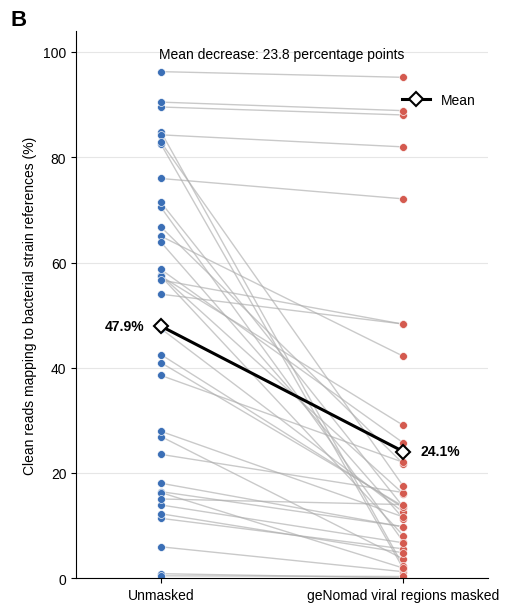

Saved paired plot for 36 viromes: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_strain_mapping_before_after_genomad_viral_region_masking_paired.svg
Mean mapping: 47.9% before, 24.1% after; mean decrease: 23.8 percentage points.


In [13]:
# Plot paired mapping before and after viral-region masking
paired_mapping = pd.read_csv(outputs['strain_mapping_masking'])
before_column = '% unmasked strain references'
after_column = '% geNomad-viral-region-masked strain references'
required_columns = {'sample', before_column, after_column}
if not required_columns.issubset(paired_mapping.columns):
    raise ValueError(
        f'Paired-plot input is missing columns: ' 
        f'{sorted(required_columns - set(paired_mapping.columns))}'
    )
if len(paired_mapping) != len(SAMPLES_36) or paired_mapping['sample'].nunique() != len(SAMPLES_36):
    raise ValueError(f'Expected one paired observation for each of {len(SAMPLES_36)} viromes.')
if set(paired_mapping['sample']) != set(SAMPLES_36):
    raise ValueError('Paired-plot samples do not match the 36-sample manifest.')

paired_values = paired_mapping[[before_column, after_column]].apply(
    pd.to_numeric, errors='coerce'
)
if paired_values.isna().any().any():
    raise ValueError('Paired-plot input contains missing or non-numeric percentages.')

before_mean, after_mean = paired_values.mean()
mean_decrease = (paired_values[before_column] - paired_values[after_column]).mean()

fig, axis = plt.subplots(figsize=(5.2, 6.2))
for before, after in paired_values.itertuples(index=False, name=None):
    axis.plot([0, 1], [before, after], color='0.68', linewidth=1, alpha=0.65, zorder=1)
axis.scatter(
    np.zeros(len(paired_values)), paired_values[before_column],
    s=32, color='#3B6FB6', edgecolor='white', linewidth=0.45, zorder=2,
)
axis.scatter(
    np.ones(len(paired_values)), paired_values[after_column],
    s=32, color='#D45A4F', edgecolor='white', linewidth=0.45, zorder=2,
)
axis.plot(
    [0, 1], [before_mean, after_mean], color='black', linewidth=2.2,
    marker='D', markersize=7, markerfacecolor='white', markeredgewidth=1.5,
    label='Mean', zorder=3,
)
axis.annotate(
    f'{before_mean:.1f}%', (0, before_mean), xytext=(-12, 0),
    textcoords='offset points', ha='right', va='center', fontsize=10, fontweight='bold',
)
axis.annotate(
    f'{after_mean:.1f}%', (1, after_mean), xytext=(12, 0),
    textcoords='offset points', ha='left', va='center', fontsize=10, fontweight='bold',
)
axis.text(
    0.5, 0.97, f'Mean decrease: {mean_decrease:.1f} percentage points',
    transform=axis.transAxes, ha='center', va='top', fontsize=10,
)
axis.text(-0.16, 1.04, 'B', transform=axis.transAxes, fontsize=16, fontweight='bold', va='top')
axis.set_xticks([0, 1], ['Unmasked', 'geNomad viral regions masked'])
axis.set_xlim(-0.35, 1.35)
axis.set_ylim(0, max(100, paired_values.to_numpy().max() * 1.08))
axis.set_ylabel('Clean reads mapping to bacterial strain references (%)')
axis.legend(frameon=False, loc='upper right', bbox_to_anchor=(1, 0.91))
axis.spines[['top', 'right']].set_visible(False)
axis.grid(axis='y', color='0.9', linewidth=0.8)
axis.set_axisbelow(True)
fig.tight_layout()
fig.savefig(outputs['strain_mapping_masking_plot'], format='svg', bbox_inches='tight')
plt.show()
plt.close(fig)

print(
    f'Saved paired plot for {len(paired_mapping)} viromes: ' 
    f'{outputs["strain_mapping_masking_plot"]}'
)
print(
    f'Mean mapping: {before_mean:.1f}% before, {after_mean:.1f}% after; ' 
    f'mean decrease: {mean_decrease:.1f} percentage points.'
)


## Detected Bacterial Reference Genomes and geNomad Proviruses

The main supplementary table is `08_detected_bacterial_reference_genomes_breadth30.csv`. Each row is a bacterial reference genome with at least 30% genome breadth in one or more of the 36 viromes using the geNomad-viral-region-masked reference. It retains genome identity, taxonomy, detection breadth and abundance, and the number, total length, presence, and genome fraction of explicit geNomad `Provirus` intervals. In total, 374 bacterial reference genomes were detected in 33 of 36 viromes, representing 21 genera and 137 species; 338 of 374 genomes (90.4%) contained at least one explicit geNomad `Provirus` interval. The downstream eligible-host analysis further retained 824 intervals in 323 genomes after requiring host contigs >=100 kb and <80% merged geNomad viral coverage.


In [14]:
# Summarize detected bacterial genomes and geNomad proviruses
strain_coverage = pd.read_csv(STRAIN_REFERENCE_COVERAGE_PATH)
required_detection_columns = {'sample', 'genome', 'genome_covered_fraction', 'superkingdom'}
missing_detection_columns = required_detection_columns.difference(strain_coverage.columns)
if missing_detection_columns:
    raise ValueError(f'Strain-reference coverage table is missing: {sorted(missing_detection_columns)}')
observed_min_breadth = pd.to_numeric(
    strain_coverage['genome_covered_fraction'], errors='coerce'
).min()
if pd.isna(observed_min_breadth) or observed_min_breadth < MIN_DETECTED_GENOME_BREADTH - 1e-12:
    raise ValueError(
        f'Expected the canonical >=30% breadth table, but its minimum breadth is '
        f'{observed_min_breadth!r}. Rerun the strain-reference coverage block in Notebook 07.'
    )
strain_coverage['sample'] = strain_coverage['sample'].astype(str).str.replace('_T$', '', regex=True)
strain_coverage = strain_coverage.loc[
    strain_coverage['sample'].isin(SAMPLES_36)
    & strain_coverage['superkingdom'].eq('Bacteria')
].copy()
detected_coverage = strain_coverage.loc[
    strain_coverage['genome_covered_fraction'] >= MIN_DETECTED_GENOME_BREADTH
].copy()
if detected_coverage.empty:
    raise ValueError('No bacterial strain-reference genomes meet the 30% genome-breadth threshold.')

taxonomy_columns = [
    column for column in [
        'taxid', 'superkingdom', 'kingdom', 'phylum', 'class', 'order', 'family',
        'genus', 'species', 'strain', 'genome_size',
    ] if column in detected_coverage.columns
]
genome_aggregations = {
    'n_viromes_detected': ('sample', 'nunique'),
    'viromes_detected': (
        'sample',
        lambda values: ';'.join(sample for sample in SAMPLES_36 if sample in set(values)),
    ),
    'max_genome_breadth': ('genome_covered_fraction', 'max'),
    'median_genome_breadth': ('genome_covered_fraction', 'median'),
    'max_genome_breadth_percent': ('genome_covered_percentage', 'max'),
    'max_rpkm': ('max_rpkm', 'max'),
    'total_mapped_reads': ('read_count', 'sum'),
    'max_pct_clean_reads': ('pct_of_clean_reads', 'max'),
    'max_pct_strain_reference_reads': ('pct_of_strain_reference_mapped_reads', 'max'),
    'genome_length': ('genome_length', 'max'),
}
for column in taxonomy_columns:
    genome_aggregations[column] = (column, 'first')

detected_before_prophage_annotation = (
    detected_coverage.groupby('genome', as_index=False)
    .agg(**genome_aggregations)
    .sort_values(
        ['n_viromes_detected', 'max_genome_breadth', 'max_rpkm'],
        ascending=False,
    )
    .reset_index(drop=True)
)

strain_contig_columns = [
    'target_seq', 'sequence_length', 'A', 'C', 'G', 'T', '#2', '#3', '#4',
    '#CpG', '#tv', '#ts', '#CpG-ts', 'genome',
]
strain_contigs = pd.read_csv(
    STRAIN_CONTIG_METADATA_PATH,
    sep='	',
    header=None,
    names=strain_contig_columns,
    usecols=[0, 1, 13],
)
strain_contigs['target_seq'] = strain_contigs['target_seq'].astype(str).str.strip()
strain_contigs['genome'] = strain_contigs['genome'].astype(str).str.strip()
strain_contigs = strain_contigs.drop_duplicates('target_seq')

genomad_regions = pd.read_csv(GENOMAD_VIRAL_REGIONS_PATH, sep='	')
if 'topology' not in genomad_regions.columns:
    raise ValueError('geNomad region table lacks the topology column required to identify Provirus intervals.')
explicit_proviruses = genomad_regions.loc[genomad_regions['topology'].eq('Provirus')].copy()
explicit_proviruses['target_seq'] = explicit_proviruses['target_seq'].astype(str).str.strip()
explicit_proviruses = explicit_proviruses.merge(
    strain_contigs[['target_seq', 'genome']],
    on='target_seq',
    how='left',
)
if explicit_proviruses['genome'].isna().any():
    missing_contigs = explicit_proviruses.loc[
        explicit_proviruses['genome'].isna(), 'target_seq'
    ].head(5).tolist()
    raise ValueError(f'Could not assign geNomad regions to strain genomes: {missing_contigs}')

provirus_summary = (
    explicit_proviruses.groupby('genome', as_index=False)
    .agg(
        n_explicit_genomad_provirus_intervals=('target_seq', 'size'),
        total_explicit_genomad_provirus_length_bp=('predicted_region_length', 'sum'),
        max_provirus_virus_score=('virus_score', 'max'),
        total_provirus_hallmarks=('n_hallmarks', 'sum'),
    )
)
detected_genomes = detected_before_prophage_annotation.merge(
    provirus_summary,
    on='genome',
    how='left',
)
for column in [
    'n_explicit_genomad_provirus_intervals',
    'total_explicit_genomad_provirus_length_bp',
    'total_provirus_hallmarks',
]:
    detected_genomes[column] = detected_genomes[column].fillna(0).astype(int)
detected_genomes['has_explicit_genomad_provirus'] = detected_genomes[
    'n_explicit_genomad_provirus_intervals'
].gt(0)
detected_genomes['explicit_genomad_provirus_fraction'] = (
    detected_genomes['total_explicit_genomad_provirus_length_bp']
    / detected_genomes['genome_length'].replace(0, np.nan)
)
supplementary_table_columns = [
    'genome', 'taxid', 'superkingdom', 'kingdom', 'phylum', 'class', 'order',
    'family', 'genus', 'species', 'strain', 'genome_size', 'genome_length',
    'n_viromes_detected', 'viromes_detected', 'max_genome_breadth',
    'median_genome_breadth', 'max_genome_breadth_percent', 'max_rpkm',
    'total_mapped_reads', 'max_pct_clean_reads',
    'max_pct_strain_reference_reads', 'n_explicit_genomad_provirus_intervals',
    'total_explicit_genomad_provirus_length_bp', 'has_explicit_genomad_provirus',
    'explicit_genomad_provirus_fraction', 'max_provirus_virus_score',
    'total_provirus_hallmarks',
]
detected_genomes = detected_genomes[supplementary_table_columns]
if detected_genomes.columns[0] != 'genome':
    raise ValueError('The detected-genome supplementary table must begin with genome.')
detected_genomes.to_csv(outputs['detected_genomes'], index=False)
detected_genomes.to_csv(
    SUP_FIGS_TABLES_DIR / "STableX2_detected_bacterial_references_proviruses.csv",
    index=False,
)

taxonomy_summary = (
    detected_genomes.groupby(['phylum', 'genus'], dropna=False, as_index=False)
    .agg(
        n_detected_reference_genomes=('genome', 'nunique'),
        total_virome_detections=('n_viromes_detected', 'sum'),
        genomes_with_explicit_genomad_provirus=('has_explicit_genomad_provirus', 'sum'),
        max_breadth_percent=('max_genome_breadth_percent', 'max'),
    )
    .sort_values(
        ['total_virome_detections', 'n_detected_reference_genomes'],
        ascending=False,
    )
)
taxonomy_summary.to_csv(outputs['taxonomy'], index=False)

detected_genome_summary = pd.DataFrame(
    [
        {
            "metric": "Detected bacterial reference genomes (>=30% breadth)",
            "value": detected_genomes["genome"].nunique(),
        },
        {
            "metric": "Viromes with at least one detected bacterial reference genome",
            "value": detected_coverage["sample"].nunique(),
        },
        {
            "metric": "Detected bacterial genera",
            "value": detected_genomes["genus"].dropna().nunique(),
        },
        {
            "metric": "Detected bacterial species",
            "value": detected_genomes["species"].dropna().nunique(),
        },
        {
            "metric": "Detected genomes with >=1 explicit geNomad Provirus interval",
            "value": int(detected_genomes["has_explicit_genomad_provirus"].sum()),
        },
        {
            "metric": "Detected genomes with >=1 explicit geNomad Provirus interval (%)",
            "value": round(
                100 * detected_genomes["has_explicit_genomad_provirus"].mean(),
                1,
            ),
        },
    ]
)
detected_genome_summary.to_csv(outputs["detected_genome_summary"], index=False)

display(detected_genome_summary)

display(detected_genomes)
display(taxonomy_summary.head(30))


,metric,value
0,Detected bacterial reference genomes (>=30% br...,374.0
1,Viromes with at least one detected bacterial r...,33.0
2,Detected bacterial genera,21.0
3,Detected bacterial species,137.0
4,Detected genomes with >=1 explicit geNomad Pro...,338.0
5,Detected genomes with >=1 explicit geNomad Pro...,90.4


,genome,taxid,superkingdom,kingdom,phylum,class,order,family,genus,species,...,max_rpkm,total_mapped_reads,max_pct_clean_reads,max_pct_strain_reference_reads,n_explicit_genomad_provirus_intervals,total_explicit_genomad_provirus_length_bp,has_explicit_genomad_provirus,explicit_genomad_provirus_fraction,max_provirus_virus_score,total_provirus_hallmarks
0,Erwinia_aphidicola_B09_9,68334,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Erwiniaceae,Erwinia,Erwinia aphidicola,...,1141.628800,55417915,17.373126,19.709820,6,241062,True,0.051276,0.9755,101
1,GCF_024462615.1_ASM2446261v1,1747,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Propionibacteriales,Propionibacteriaceae,Cutibacterium,Cutibacterium acnes,...,15.471131,558900,0.160808,2.497146,0,0,False,0.000000,NaN,0
2,GCF_963878835.1_ena-yuan-GCF_003122445.1,138072,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Candidatus Williamhamiltonella,Candidatus Williamhamiltonella defendens,...,45.280050,1230115,0.317550,9.572413,3,138177,True,0.060985,0.9602,55
3,GCF_902859575.1_HaCicuneomaculata_2628_v1.0,138072,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Candidatus Williamhamiltonella,Candidatus Williamhamiltonella defendens,...,517.799700,1221624,0.441231,17.520228,2,23729,True,0.011872,0.9450,17
4,GCF_002777235.1_ASM277723v1,138072,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Candidatus Williamhamiltonella,Candidatus Williamhamiltonella defendens,...,123.223740,1623768,0.480487,26.773209,6,245036,True,0.107820,0.9581,88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,GCF_002563895.1_ASM256389v1,244566,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,Pseudomonas lurida,...,0.210996,38137,0.034232,0.133173,1,18739,True,0.002969,0.9555,12
370,GCF_014842725.1_ASM1484272v1,2774039,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,Pseudomonas sp. CFBP 13602,...,1.277528,20670,0.022326,0.025124,1,47866,True,0.010022,0.9731,13
371,GCF_900006605.1_PSEFL294_LIB5413,1844108,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,Pseudomonas sp. 58 R 3,...,0.527381,35698,0.038559,0.043390,2,65272,True,0.009810,0.9596,34
372,GCF_014268265.1_ASM1426826v1,244566,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,Pseudomonas lurida,...,0.969991,36324,0.032605,0.126842,2,75051,True,0.012019,0.9688,27


,phylum,genus,n_detected_reference_genomes,total_virome_detections,genomes_with_explicit_genomad_provirus,max_breadth_percent
14,Pseudomonadota,Pantoea,179,1001,167,97.765103
10,Pseudomonadota,Erwinia,35,239,34,96.687630
15,Pseudomonadota,Pseudomonas,87,221,85,96.732707
9,Pseudomonadota,Candidatus Williamhamiltonella,7,83,7,95.226402
16,Pseudomonadota,Rahnella,15,65,15,96.274618
2,Actinomycetota,Frigoribacterium,13,21,3,64.197577
1,Actinomycetota,Cutibacterium,2,19,0,97.277755
18,Pseudomonadota,Sphingomonas,13,15,12,80.157489
5,Actinomycetota,Sanguibacter,3,6,1,93.808517
17,Pseudomonadota,Rickettsiella,1,6,0,97.182439


## Species Coverage-Ranked Strain Heatmap

This recreates the final heatmap from the mapping notebook. Species are selected by
aggregate genome breadth, while cell color remains `log10(RPKM + 1)`. Within each
species and sample, the displayed reference is the strain with the greatest genome
breadth; ties use RPKM, read count, then genome ID. Rows are grouped by genus, with
genera ordered by their total breadth signal and white divider lines between them.


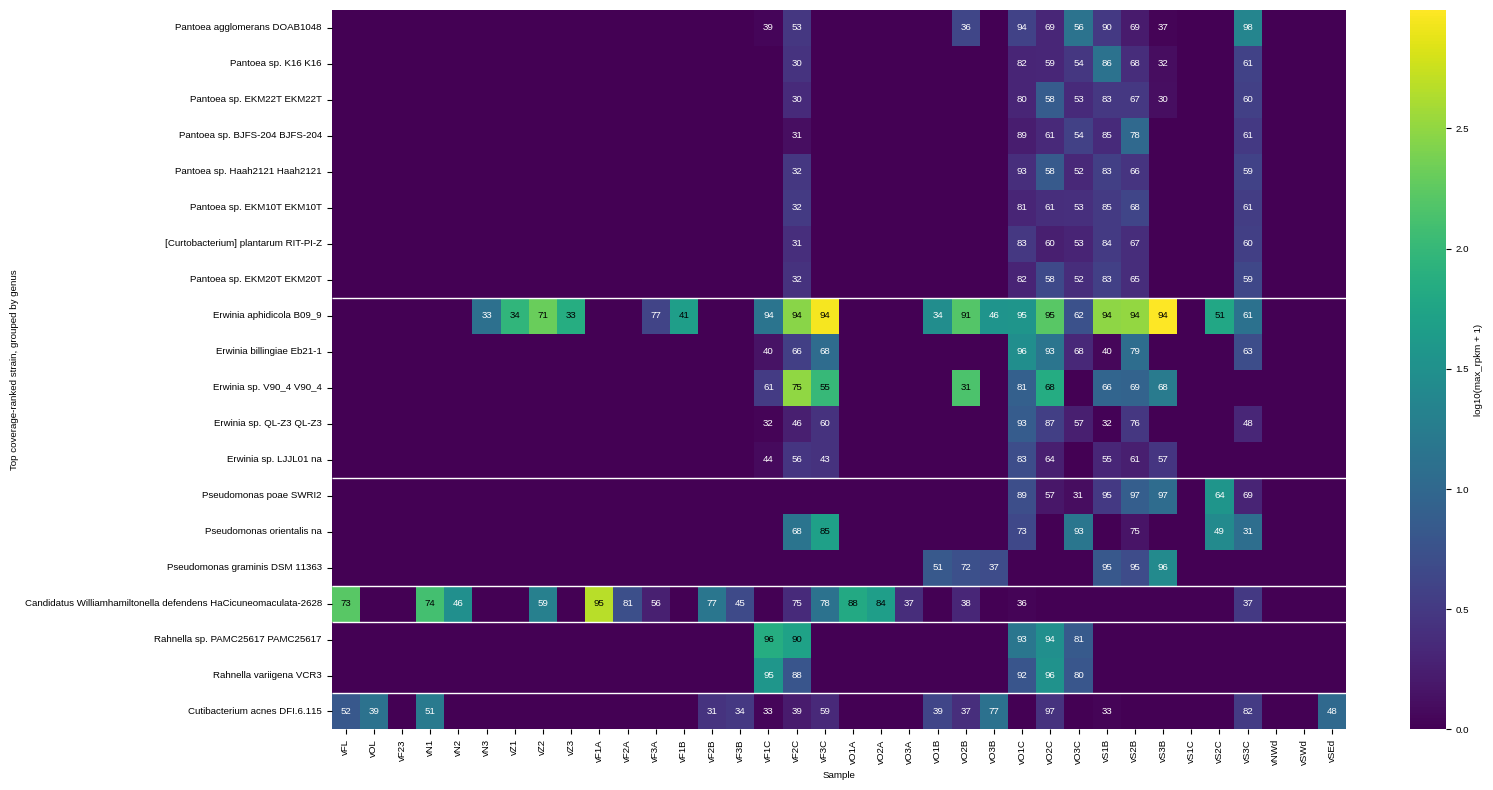

Saved coverage-ranked row metadata: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_species_coverage_ranked_row_metadata.csv
Saved coverage-ranked RPKM matrix: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_species_coverage_ranked_rpkm_matrix.csv
Saved coverage-ranked breadth matrix: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_species_coverage_ranked_genome_coverage_matrix.csv
Saved selected-genome matrix: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_species_coverage_ranked_selected_genome_matrix.csv
Saved selected-strain matrix: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_species_coverage_ranked_selected_strain_matrix.csv
Saved heatmap SVG: /home/lm

In [15]:
# Plot the species coverage-ranked strain heatmap
TOP_N_SPECIES = 20
COVERAGE_COLUMN = 'genome_covered_percentage'
RPKM_COLOR_COLUMN = 'max_rpkm'
PLOT_LOG10_RPKM = True
HEATMAP_XTICK_FONT_SIZE = 7
HEATMAP_YTICK_FONT_SIZE = 7
HEATMAP_AXIS_LABEL_FONT_SIZE = 7
HEATMAP_TITLE_FONT_SIZE = 7
HEATMAP_ANNOT_FONT_SIZE = 7

def first_nonempty(values):
    values = pd.Series(values).dropna().astype(str)
    values = values[values.str.strip().ne('') & values.str.lower().ne('nan')]
    return values.iloc[0] if len(values) else np.nan

def clean_taxonomic_group(values, fallback):
    group = values.astype('string')
    group = group.mask(group.str.strip().eq(''), pd.NA)
    group = group.mask(group.str.lower().eq('nan'), pd.NA)
    return group.fillna(fallback.astype(str))

def add_taxonomic_groups(frame):
    species_group = clean_taxonomic_group(frame['species'], frame['genome'])
    fallback_genus = species_group.astype(str).str.split().str[0]
    genus_group = clean_taxonomic_group(frame['genus'], fallback_genus)
    return frame.assign(
        species_group=species_group.astype(str),
        genus_group=genus_group.astype(str),
    )

def matrix_with_row_metadata(matrix, row_metadata=None):
    output = matrix.reset_index().rename(columns={'species_group': 'species'})
    if row_metadata is not None:
        metadata_columns = [
            'species', 'row_label', 'genus', 'genus_total_coverage',
            'species_total_coverage', 'species_max_coverage',
            'species_mean_coverage_detected', 'top_coverage_genome',
            'top_coverage_strain', 'top_strain_max_coverage',
            'top_strain_total_coverage', 'n_samples_detected',
            'species_total_max_rpkm', 'species_total_mapped_reads',
        ]
        metadata_columns = [
            column for column in metadata_columns if column in row_metadata.columns
        ]
        output = output.merge(row_metadata[metadata_columns], on='species', how='left')
        sample_columns = [column for column in output.columns if column in SAMPLES_36]
        output = output[
            [column for column in metadata_columns if column in output.columns] + sample_columns
        ]
    return output

def coverage_annotation_strings(coverage_matrix, rpkm_matrix):
    coverage_for_labels = coverage_matrix.where(rpkm_matrix > 0)
    return coverage_for_labels.apply(
        lambda column: column.map(
            lambda value: '' if pd.isna(value) else f'{value:.0f}'
        )
    )

strain_source = pd.read_csv(STRAIN_REFERENCE_COVERAGE_PATH)
required_columns = {'sample', 'genome', RPKM_COLOR_COLUMN, COVERAGE_COLUMN, 'read_count'}
if not required_columns.issubset(strain_source.columns):
    raise ValueError(f'Heatmap input is missing columns: {sorted(required_columns - set(strain_source.columns))}')

strain_source = strain_source.copy()
strain_source[RPKM_COLOR_COLUMN] = pd.to_numeric(
    strain_source[RPKM_COLOR_COLUMN], errors='coerce'
).fillna(0)
strain_source[COVERAGE_COLUMN] = pd.to_numeric(
    strain_source[COVERAGE_COLUMN], errors='coerce'
).fillna(0)
strain_source['read_count'] = pd.to_numeric(strain_source['read_count'], errors='coerce').fillna(0)
strain_source = strain_source.loc[strain_source['sample'].isin(SAMPLES_36)].copy()
strain_source = add_taxonomic_groups(strain_source)
if 'strain' not in strain_source.columns:
    strain_source['strain'] = np.nan

# One strain per species/sample: highest breadth, then RPKM, reads, and genome ID.
species_sample_top = (
    strain_source
    .sort_values(
        ['species_group', 'sample', COVERAGE_COLUMN, RPKM_COLOR_COLUMN, 'read_count', 'genome'],
        ascending=[True, True, False, False, False, True],
    )
    .drop_duplicates(['species_group', 'sample'], keep='first')
)

species_signal = (
    species_sample_top
    .groupby(['genus_group', 'species_group'], as_index=False)
    .agg(
        species_total_coverage=(COVERAGE_COLUMN, 'sum'),
        species_max_coverage=(COVERAGE_COLUMN, 'max'),
        species_mean_coverage_detected=(COVERAGE_COLUMN, 'mean'),
        species_total_max_rpkm=(RPKM_COLOR_COLUMN, 'sum'),
        species_total_mapped_reads=('read_count', 'sum'),
        n_samples_detected=('sample', 'nunique'),
    )
)
top_strain_by_coverage = (
    strain_source
    .groupby(['genus_group', 'species_group', 'genome'], as_index=False)
    .agg(
        top_strain_total_coverage=(COVERAGE_COLUMN, 'sum'),
        top_strain_max_coverage=(COVERAGE_COLUMN, 'max'),
        top_strain_total_max_rpkm=(RPKM_COLOR_COLUMN, 'sum'),
        top_strain_mapped_reads=('read_count', 'sum'),
        top_coverage_strain=('strain', first_nonempty),
    )
    .sort_values(
        [
            'species_group', 'top_strain_total_coverage',
            'top_strain_max_coverage', 'top_strain_total_max_rpkm',
            'top_strain_mapped_reads', 'genome',
        ],
        ascending=[True, False, False, False, False, True],
    )
    .drop_duplicates('species_group', keep='first')
    .rename(columns={'genome': 'top_coverage_genome'})
)
heatmap_rows = (
    species_signal
    .merge(
        top_strain_by_coverage[
            [
                'species_group', 'top_coverage_genome', 'top_coverage_strain',
                'top_strain_total_coverage', 'top_strain_max_coverage',
                'top_strain_total_max_rpkm', 'top_strain_mapped_reads',
            ]
        ],
        on='species_group',
        how='left',
    )
    .rename(columns={'species_group': 'species', 'genus_group': 'genus'})
    .sort_values(
        ['species_total_coverage', 'species_max_coverage', 'n_samples_detected', 'species_total_max_rpkm'],
        ascending=False,
    )
    .head(TOP_N_SPECIES)
)
genus_signal = (
    heatmap_rows.groupby('genus', as_index=False)
    .agg(
        genus_total_coverage=('species_total_coverage', 'sum'),
        genus_max_coverage=('species_max_coverage', 'max'),
        n_species_in_heatmap=('species', 'nunique'),
    )
)
heatmap_rows = heatmap_rows.merge(genus_signal, on='genus', how='left')
has_strain_label = (
    heatmap_rows['top_coverage_strain'].notna()
    & heatmap_rows['top_coverage_strain'].astype(str).str.strip().ne('')
    & heatmap_rows['top_coverage_strain'].astype(str).str.lower().ne('nan')
)
heatmap_rows['row_label'] = np.where(
    has_strain_label,
    heatmap_rows['top_coverage_strain'].astype(str),
    heatmap_rows['species'].astype(str),
)
heatmap_rows = (
    heatmap_rows.assign(
        genus_sort=lambda frame: frame['genus'].str.lower(),
        species_sort=lambda frame: frame['species'].str.lower(),
    )
    .sort_values(
        ['genus_total_coverage', 'genus_sort', 'species_total_coverage', 'species_sort'],
        ascending=[False, True, False, True],
    )
    .drop(columns=['genus_sort', 'species_sort'])
    .reset_index(drop=True)
)

ordered_species = heatmap_rows['species'].tolist()
selected_species_sample_rows = species_sample_top.loc[
    species_sample_top['species_group'].isin(ordered_species)
].copy()
species_rpkm_matrix = (
    selected_species_sample_rows
    .pivot_table(
        index='species_group', columns='sample', values=RPKM_COLOR_COLUMN,
        aggfunc='max', fill_value=0,
    )
    .reindex(index=ordered_species)
    .reindex(columns=SAMPLES_36, fill_value=0)
)
species_coverage_matrix = (
    selected_species_sample_rows
    .pivot_table(
        index='species_group', columns='sample', values=COVERAGE_COLUMN, aggfunc='max',
    )
    .reindex(index=ordered_species)
    .reindex(columns=SAMPLES_36)
)
selected_genome_matrix = (
    selected_species_sample_rows
    .pivot_table(
        index='species_group', columns='sample', values='genome', aggfunc=first_nonempty,
    )
    .reindex(index=ordered_species)
    .reindex(columns=SAMPLES_36)
)
selected_strain_matrix = (
    selected_species_sample_rows
    .pivot_table(
        index='species_group', columns='sample', values='strain', aggfunc=first_nonempty,
    )
    .reindex(index=ordered_species)
    .reindex(columns=SAMPLES_36)
)

heatmap_rows.to_csv(outputs['heatmap_row_metadata'], index=False)
matrix_with_row_metadata(species_rpkm_matrix, heatmap_rows).to_csv(
    outputs['heatmap_rpkm_matrix'], index=False
)
matrix_with_row_metadata(species_coverage_matrix.round(0).astype('Int64'), heatmap_rows).to_csv(
    outputs['heatmap_breadth_matrix'], index=False
)
matrix_with_row_metadata(selected_genome_matrix).to_csv(
    outputs['heatmap_selected_genome_matrix'], index=False
)
matrix_with_row_metadata(selected_strain_matrix).to_csv(
    outputs['heatmap_selected_strain_matrix'], index=False
)

row_label_map = heatmap_rows.set_index('species')['row_label'].to_dict()
plot_rpkm_matrix = species_rpkm_matrix.rename(index=row_label_map)
plot_coverage_matrix = species_coverage_matrix.rename(index=row_label_map)
heatmap_values = np.log10(plot_rpkm_matrix + 1) if PLOT_LOG10_RPKM else plot_rpkm_matrix
coverage_annotations = coverage_annotation_strings(plot_coverage_matrix, plot_rpkm_matrix)

fig_height = max(8, 0.28 * len(plot_rpkm_matrix))
fig_width = max(14, 0.45 * len(plot_rpkm_matrix.columns))
fig, axis = plt.subplots(figsize=(fig_width, fig_height))
sns.heatmap(
    heatmap_values,
    cmap='viridis',
    linewidths=0,
    ax=axis,
    annot=coverage_annotations,
    fmt='',
    annot_kws={'fontsize': HEATMAP_ANNOT_FONT_SIZE},
    cbar_kws={'label': 'log10(max_rpkm + 1)'},
)
axis.set_xticks(np.arange(len(plot_rpkm_matrix.columns)) + 0.5)
axis.set_xticklabels(
    plot_rpkm_matrix.columns,
    rotation=90,
    ha='center',
    fontsize=HEATMAP_XTICK_FONT_SIZE,
)
axis.set_yticks(np.arange(len(plot_rpkm_matrix.index)) + 0.5)
axis.set_yticklabels(
    plot_rpkm_matrix.index,
    rotation=0,
    fontsize=HEATMAP_YTICK_FONT_SIZE,
)

genus_order = heatmap_rows.set_index('species').loc[species_rpkm_matrix.index, 'genus']
genus_boundaries = np.where(genus_order.ne(genus_order.shift()).to_numpy()[1:])[0] + 1
for boundary in genus_boundaries:
    axis.hlines(boundary, *axis.get_xlim(), colors='white', linewidth=1)

max_heatmap_value = np.nanmax(heatmap_values.to_numpy()) if heatmap_values.size else 0
for text, value in zip(axis.texts, heatmap_values.to_numpy().ravel()):
    if text.get_text():
        text.set_color(
            'black' if max_heatmap_value and value > max_heatmap_value * 0.55 else 'white'
        )

axis.set_xlabel('Sample', fontsize=HEATMAP_AXIS_LABEL_FONT_SIZE)
axis.set_ylabel(
    'Top coverage-ranked strain, grouped by genus',
    fontsize=HEATMAP_AXIS_LABEL_FONT_SIZE,
)
axis.figure.axes[-1].yaxis.label.set_size(HEATMAP_AXIS_LABEL_FONT_SIZE)
axis.figure.axes[-1].tick_params(labelsize=HEATMAP_XTICK_FONT_SIZE)
fig.tight_layout()
fig.savefig(outputs['heatmap'], format='svg', bbox_inches='tight')
plt.show()
plt.close(fig)

print(f'Saved coverage-ranked row metadata: {outputs["heatmap_row_metadata"]}')
print(f'Saved coverage-ranked RPKM matrix: {outputs["heatmap_rpkm_matrix"]}')
print(f'Saved coverage-ranked breadth matrix: {outputs["heatmap_breadth_matrix"]}')
print(f'Saved selected-genome matrix: {outputs["heatmap_selected_genome_matrix"]}')
print(f'Saved selected-strain matrix: {outputs["heatmap_selected_strain_matrix"]}')
print(f'Saved heatmap SVG: {outputs["heatmap"]}')


## Combined Figure

Panel A shows the coverage-ranked strain heatmap. Panel B, placed directly below it, shows the paired percentage of clean reads mapping to bacterial strain references before and after masking all geNomad-predicted viral regions.


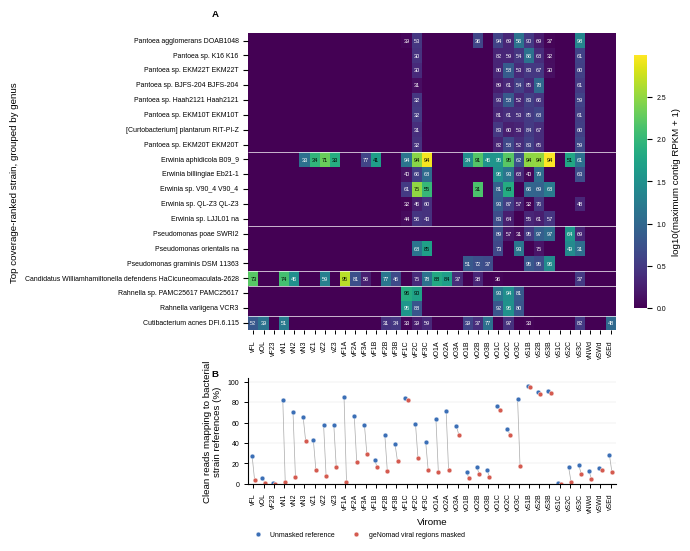

Saved combined panels A and B: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/08_microbial_signal_in_viromes/08_microbial_signal_in_viromes_panels_A_B.svg


In [ ]:
# Assemble and export the combined figure
combined_paired = (
    pd.read_csv(outputs['strain_mapping_masking'])
    .set_index('sample')
    .reindex(SAMPLES_36)
    .reset_index()
)
combined_values = combined_paired[[before_column, after_column]].apply(
    pd.to_numeric, errors='coerce'
)
if len(combined_values) != len(SAMPLES_36) or combined_values.isna().any().any():
    raise ValueError('Combined figure requires complete paired values for all 36 viromes.')
# Match the full-width heatmap convention in the main abundance figures.
# Typography there is generally 5-7 pt, with a 6.8-inch heatmap canvas.
combined_width = 6.8
combined_height = 5.4
combined_heatmap_height = 2.8
combined_paired_height = 1.0
combined_tick_font_size = 5
combined_label_font_size = 7
combined_annot_font_size = 4
combined_panel_font_size = 7
combined_legend_font_size = 5
combined_figure = plt.figure(
    figsize=(combined_width, combined_height),
    constrained_layout=True,
)
combined_grid = combined_figure.add_gridspec(
    2, 1,
    height_ratios=[combined_heatmap_height, combined_paired_height],
    hspace=0.04,
)
heatmap_axis = combined_figure.add_subplot(combined_grid[0])
paired_axis = combined_figure.add_subplot(combined_grid[1], sharex=heatmap_axis)

heatmap_plot = sns.heatmap(
    heatmap_values,
    cmap='viridis',
    linewidths=0,
    ax=heatmap_axis,
    annot=coverage_annotations,
    fmt='',
    annot_kws={'fontsize': combined_annot_font_size},
    cbar_kws={'label': 'log10(maximum contig RPKM + 1)', 'shrink': 0.85},
)
heatmap_axis.set_xticks(
    np.arange(len(plot_rpkm_matrix.columns)) + 0.5,
    plot_rpkm_matrix.columns,
)
# Show virome labels in both panels so each panel can be read independently.
heatmap_axis.tick_params(
    axis='x', bottom=True, labelbottom=True, labelrotation=90,
    labelsize=combined_tick_font_size, width=0.7, length=3,
)
heatmap_axis.set_yticks(np.arange(len(plot_rpkm_matrix.index)) + 0.5)
heatmap_axis.set_yticklabels(
    plot_rpkm_matrix.index, rotation=0, fontsize=combined_tick_font_size,
)
for boundary in genus_boundaries:
    heatmap_axis.hlines(
        boundary, *heatmap_axis.get_xlim(), colors='white', linewidth=0.5
    )
for text, value in zip(heatmap_axis.texts, heatmap_values.to_numpy().ravel()):
    if text.get_text():
        text.set_color(
            'black'
            if max_heatmap_value and value > max_heatmap_value * 0.55
            else 'white'
        )
heatmap_axis.set_xlabel('')
heatmap_axis.set_ylabel(
    'Top coverage-ranked strain, grouped by genus',
    fontsize=combined_label_font_size,
)
heatmap_axis.text(
    -0.10, 1.08, 'A', transform=heatmap_axis.transAxes,
    fontsize=combined_panel_font_size, fontweight='bold', va='top',
)
heatmap_plot.collections[0].colorbar.ax.yaxis.label.set_size(
    combined_label_font_size
)
heatmap_plot.collections[0].colorbar.ax.tick_params(
    labelsize=combined_tick_font_size
)

sample_positions = np.arange(len(combined_values)) + 0.5
before_positions = sample_positions - 0.12
after_positions = sample_positions + 0.12
for before_x, after_x, (before, after) in zip(
    before_positions, after_positions,
    combined_values.itertuples(index=False, name=None),
):
    paired_axis.plot(
        [before_x, after_x], [before, after], color='0.58', linewidth=0.5,
        alpha=0.8, zorder=1,
    )
paired_axis.scatter(
    before_positions, combined_values[before_column],
    s=12, color='#3B6FB6', edgecolor='white', linewidth=0.3, zorder=2,
    label='Unmasked reference',
)
paired_axis.scatter(
    after_positions, combined_values[after_column],
    s=12, color='#D45A4F', edgecolor='white', linewidth=0.3, zorder=2,
    label='geNomad viral regions masked',
)
paired_axis.text(
    -0.10, 1.08, 'B', transform=paired_axis.transAxes,
    fontsize=combined_panel_font_size, fontweight='bold', va='top',
)
paired_axis.set_xticks(sample_positions, SAMPLES_36)
paired_axis.tick_params(
    axis='x', labelrotation=90, labelsize=combined_tick_font_size,
    width=0.7, length=3,
)
paired_axis.tick_params(
    axis='y', labelsize=combined_tick_font_size, width=0.7, length=3
)
paired_axis.set_xlim(0, len(SAMPLES_36))
paired_axis.set_ylim(0, max(100, combined_values.to_numpy().max() * 1.08))
paired_axis.set_ylabel(
    'Clean reads mapping to bacterial\nstrain references (%)',
    fontsize=combined_label_font_size,
)
paired_axis.set_xlabel('Virome', fontsize=combined_label_font_size)
paired_axis.legend(
    frameon=False, loc='upper left', bbox_to_anchor=(0.0, -0.42),
    fontsize=combined_legend_font_size, ncol=2, borderaxespad=0,
)
paired_axis.spines[['top', 'right']].set_visible(False)
paired_axis.grid(axis='y', color='0.9', linewidth=0.35)
paired_axis.set_axisbelow(True)

combined_figure.savefig(
    outputs['combined_figure'], format='svg', bbox_inches='tight'
)
combined_figure.savefig(
    SUP_FIGS_TABLES_DIR / "SFigureX2_microbial_signal_genomad_masking.svg",
    format='svg',
    bbox_inches='tight',
)
plt.show()
plt.close(combined_figure)
print(f'Saved combined panels A and B: {outputs["combined_figure"]}')
